# New $E_J$ Debugging Script

In [2]:
# Import the FEMSystem Class from directory above
import sys
sys.path.append('../..')
from FEMSystem import FEMSystem
import skfem as fem
from scipy.sparse.linalg import cg

import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt

# For Curve Fitting to Exponential
import numpy as np
from scipy.optimize import curve_fit

# Debugging the E_J Integral, with Modes

### Step 1: Load in an example file, and compute E_J

In [3]:
'''
Loading in File and Getting All Precomputed Results
'''

with open('./../allplots/rabilondon/rl11/results.pkl', 'rb') as f:
    pickled_obj= pickle.load(f)

femsystem:FEMSystem = pickled_obj["femsystem"]
femsystem.saveFigsDir = None # Turn OFF saving plots
u_even,u_odd = pickled_obj["u_even"],pickled_obj["u_odd"]

# Normalize the modes
u_even = u_even / np.sqrt(femsystem.integrate(lambda u,a,b: u**2,u_even))
u_odd = u_odd / np.sqrt(femsystem.integrate(lambda u,a,b: u**2,u_odd))

u_even_interior,u_odd_interior = u_even[femsystem.interior_dofs],u_odd[femsystem.interior_dofs]
u_left_interior,u_right_interior = (u_even_interior + u_odd_interior) / jnp.sqrt(2), (u_even_interior - u_odd_interior) / jnp.sqrt(2)
theta_at_dofs = pickled_obj["theta_at_dofs"]
theta_at_interior = theta_at_dofs[femsystem.interior_dofs]
n,coeffs = pickled_obj["n"],pickled_obj["coeffs"]
E_J,E_C,e_0 = pickled_obj["E_J"],pickled_obj["E_C"],pickled_obj["e0"]
parameters = pickled_obj["parameters"]
totalTime = pickled_obj["totalTime"]
material = parameters["material"]
integrated_volume = pickled_obj["integrated_volume"]
sidelenX, sidelenY, sidelenZ = parameters["sidelenX"], parameters["sidelenY"], parameters["sidelenZ"]
obj = pickled_obj["objective"]
volume = 2 * sidelenX * sidelenY * sidelenZ
N_val = integrated_volume * material
print(f"Volume Integration Error: {(integrated_volume - volume) / volume * 100:.4g}% | Integrated Volume: {integrated_volume} | Volume: {volume}")
print(f"Final Objective Value: {obj}")

print(f"EJ: {E_J:.4g}, EC: {E_C:.4g}, EJ/EC: {E_J/E_C:.4g} | Time: {int(totalTime // 60)}m {int(totalTime % 60)}s | Degrees of Freedom: {femsystem.dofs}")
print(f"Parameters:")
print(parameters)


integrand = (jnp.abs(u_even)**2 - jnp.abs(u_odd)**2)
reg = 1e9 * femsystem.integrate(lambda u,grad_u,x: u,integrand**2) 
print(femsystem.weights)
if jnp.any(femsystem.weights < 0):
    print("Warning: Some weights are negative!")
else:
    print("All weights are non-negative.")

# Check if any values in "integrand" are negative
if jnp.any(integrand < 0):
    print("Warning: There are negative values in integrand!")
else:
    print("All values in integrand are non-negative.")

interpolated_integrand = femsystem._interpolate_values(integrand)
#check that interpolated integrand is non-negative
if jnp.any(interpolated_integrand < 0):
    print("Warning: There are negative values in interpolated integrand!")
else:
    print("All values in interpolated integrand are non-negative.")


print(f"Regularizer: {reg}")

Volume Integration Error: 0.05168% | Integrated Volume: 16008.26953125 | Volume: 16000.0
Final Objective Value: -1327.1812744140625
EJ: 0.6725, EC: 1.696, EJ/EC: 0.3966 | Time: 4m 58s | Degrees of Freedom: 152596
Parameters:
{'material': 0.0033784, 'separation': 20.0, 'sidelenX': 20.0, 'sidelenY': 20.0, 'sidelenZ': 20.0, 'padding': 40.0, 'gridlenX': 140.0, 'gridlenY': 100.0, 'gridlenZ': 100.0, 'lc_large': 5.0, 'lc_small': 2.0}
[[0.5592306  0.5592306  0.5592306  ... 3.9000933  3.9000933  3.9000933 ]
 [0.7760174  0.7760174  0.7760174  ... 5.411972   5.411972   5.411972  ]
 [0.80388504 0.80388504 0.80388504 ... 5.606322   5.606322   5.606322  ]
 ...
 [0.15752062 0.15752062 0.15752062 ... 1.0985543  1.0985543  1.0985543 ]
 [0.14813356 0.14813356 0.14813356 ... 1.0330886  1.0330886  1.0330886 ]
 [0.15751186 0.15751186 0.15751186 ... 1.0984931  1.0984931  1.0984931 ]]
All weights are non-negative.
Regularizer: 0.06665592640638351


In [4]:
print(jnp.sum(u_odd**2))

0.46765


In [5]:
# Preprocess Quantities
A_int,P_int = femsystem.get_stiffness_matrix()
print("A_int generated")
theta_at_quad = femsystem._interpolate_values(theta_at_dofs)
weighted_theta = theta_at_quad * femsystem.weights
v_theta = P_int.T @ weighted_theta.ravel()
phi_theta_int = femsystem._linear_solve_cg(A_int, v_theta)

# Define all functions necessary for EJ computation
def alpha(u,A_int,P_int):
    return 1/(material) * femsystem.double_integral_cg(lambda u1,a,b,c,d: u1**2,lambda u1,a,b,c,d: u1**2,A_int,P_int,u,u)

# Really u*laplacian(u) = -(grad u)^2
def laplacian(u,grad_u,x):
    return -1*jnp.sum(grad_u**2,axis=0)

def epsilon_func_split(u_global, P_int, phi_theta_int):
    # Kinetic Term
    kinetic = -4 * femsystem.integrate(laplacian,u_global)

    # Potential Term: -2 * <u^2, G theta> = -2 * <u^2, phi_theta>
    u_quad = femsystem._interpolate_values(u_global)
    weighted_u2 = (u_quad**2) * femsystem.weights
    v_u2 = P_int.T @ weighted_u2.ravel()
    potential = -2 * (v_u2 @ phi_theta_int)
    return kinetic,potential

def epsilon_func(u_global, P_int, phi_theta_int):
    kinetic,potential = epsilon_func_split(u_global, P_int, phi_theta_int)
    return kinetic+potential

def E(u_global, A_int, P_int, phi_theta_int):
    return epsilon_func(u_global, P_int, phi_theta_int) + (N_val - 1)*alpha(u_global, A_int, P_int)

def compute_ej(u_even,u_odd,A_int,P_int,phi_theta_int):
    # Precompute shared terms to minimize CG solves
    E_plus = E(u_even, A_int, P_int, phi_theta_int)
    E_minus = E(u_odd, A_int, P_int, phi_theta_int)
    hz = ( E_plus - E_minus ) 
    E_J = -1*hz / 2 * N_val                                                                                                                                                                                                                                                                                                                                            
    return E_J

ej2 = compute_ej(u_even,u_odd,A_int,P_int,phi_theta_int)
print(f"Original E_J: {E_J}, Computed E_J: {ej2}")
epsilon_diff = epsilon_func(u_even,P_int,phi_theta_int) - epsilon_func(u_odd,P_int,phi_theta_int)
alpha_diff = (alpha(u_even,A_int,P_int) - alpha(u_odd,A_int,P_int)) * (N_val - 1)
print(f"Epsilon Diff: {epsilon_diff}")
print(f"Alpha Diff: {alpha_diff}")
print(f"EJ Per Particle: {-(alpha_diff + epsilon_diff) / 2}")
print(f"EJ Total: {-(alpha_diff + epsilon_diff) / 2 * N_val}")

********** USING TF SCREENING WITH k_tf_sq = 0.01 **********


A_int generated
Original E_J: 0.6725116968154907, Computed E_J: 0.6725632548332214
Epsilon Diff: -0.037044525146484375
Alpha Diff: 0.01216856762766838
EJ Per Particle: 0.012437978759407997
EJ Total: 0.6726750135421753


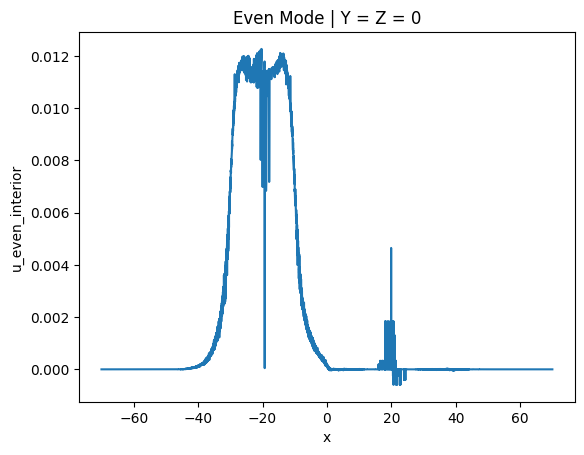

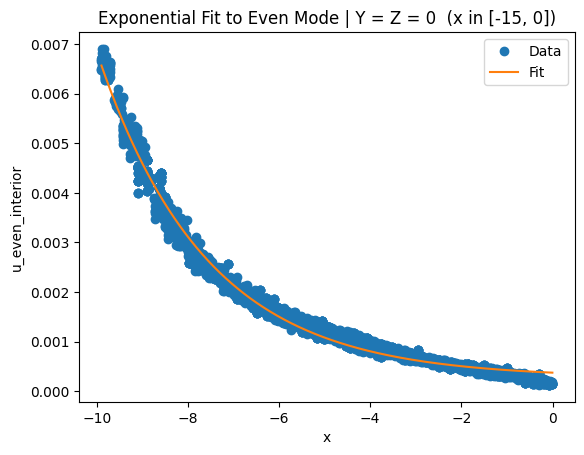

Fitted parameters: a = 9.89e-05, b = -0.4196, c = 0.0002752
R-squared: 0.9911


: 

In [ ]:
def vals_x_axis(u_interior,threshold=3):
    # For phi_theta_int plots the values closest to y=z=0, vs x-axis
    # Get the indices of dofs closest to y=0 and z=0 (within a small threshold)

    # Get the indices of the quad points closest to y=0 and z=0
    flat_coords = jnp.asarray(femsystem.coords_q_T).reshape(3, -1)
    # AND: use element-wise & on boolean arrays. Python's "and" returns one of the two sides (so you only got z<tol), not intersection.
    mask = (jnp.abs(flat_coords[1,:]) < threshold) & (jnp.abs(flat_coords[2,:]) < threshold)
    quad_indices = jnp.where(mask)[0]
    quad_coords = flat_coords[:,quad_indices]
    # Values at quadrature points (phi_theta_int is interior DOFs; quad_indices index into flattened quads)
    u_quad = jnp.asarray(femsystem._interpolate_values(femsystem._get_u_from_interior(u_interior))).flatten()
    vals = u_quad[quad_indices]

    # Sort by x for a nicer plot
    sorted_indices = jnp.argsort(quad_coords[0,:])
    x_sorted = quad_coords[0,sorted_indices]
    values_sorted = vals[sorted_indices]

    return x_sorted, values_sorted

x,val = vals_x_axis(u_right_interior,3)
plt.title("Even Mode | Y = Z = 0")
plt.plot(x,val,"-")
plt.xlabel("x")
plt.ylabel("u_even_interior")
plt.show()


# Select data in the region of interest
x_fit = np.array(x)
val_fit = np.array(val)
mask = (x_fit > -10) & (x_fit < 0)
x_window = x_fit[mask]
val_window = val_fit[mask]

def exp_func(x, a, b, c):
    return a * np.exp(b * x) + c

# Initial guess for parameters: a, b, c
p0 = [val_window.max(), -0.1, 0.0]

try:
    popt, pcov = curve_fit(exp_func, x_window, val_window, p0=p0)
    fit_vals = exp_func(x_window, *popt)

    plt.figure()
    plt.plot(x_window, val_window, "o", label="Data")
    plt.plot(x_window, fit_vals, "-", label="Fit")
    plt.title("Exponential Fit to Even Mode | Y = Z = 0  (x in [-15, 0])")
    plt.xlabel("x")
    plt.ylabel("u_even_interior")
    plt.legend()
    plt.show()
    print(f"Fitted parameters: a = {popt[0]:.4g}, b = {popt[1]:.4g}, c = {popt[2]:.4g}")
    #quality of the fit
    r_squared = 1 - np.sum((val_window - fit_vals) ** 2) / np.sum((val_window - np.mean(val_window)) ** 2)
    print(f"R-squared: {r_squared:.4g}")
except Exception as e:
    print(f"Failed to fit exponential: {e}")

In [ ]:
x,vals = vals_x_axis(phi_theta_int)
plt.title("Electrostatic Potential from Background Charge | Y = Z = 0")
plt.plot(x,vals,"-")
plt.xlabel("x")
plt.ylabel("Potential")
plt.title("Electrostatic Potential from Background Charge")
plt.show()

### Step 2: Check Expression for Alpha and Epsilon Difference 

Epsilon Difference is correct:

In [4]:
# First Check Epsilon Function
u_left = (u_even + u_odd) / jnp.sqrt(2)
u_right = (u_even - u_odd) / jnp.sqrt(2)

u_overlap = u_left * u_right

ke_plus,pe_plus = epsilon_func_split(u_even,P_int,phi_theta_int)
ke_minus,pe_minus = epsilon_func_split(u_odd,P_int,phi_theta_int)
ke_diff = ke_plus - ke_minus
pe_diff = pe_plus - pe_minus

def first_func(u1,grad_u1,u2,grad_u2,x):
    return u1
def second_func(u1,grad_u1,u2,grad_u2,x):
    return u2

def potential(u_global,P_int,phi_theta_int):
    u_quad = femsystem._interpolate_values(u_global**2)
    weighted_u2 = (u_quad) * femsystem.weights
    v_u2 = P_int.T @ weighted_u2.ravel()
    potential = -2 * (v_u2 @ phi_theta_int)
    return potential

epsilon_integral = femsystem.double_integral_cg(first_func,second_func,A_int,P_int,u_overlap,theta_at_dofs)
pe_diff2 = -4*epsilon_integral
pe_diff3 = (potential(u_even,P_int,phi_theta_int) - potential(u_odd,P_int,phi_theta_int))
print(f"PE Diff: {pe_diff}")
print(f"PE Diff 2: {pe_diff2}, going to be slightly different since squaring before, instead of after interpolation")
print(f"PE Diff 3: {pe_diff3}, going to be the same as pe_diff2")

PE Diff: 0.39879417419433594
PE Diff 2: 0.4242834448814392, going to be slightly different since squaring before, instead of after interpolation
PE Diff 3: 0.4242839813232422, going to be the same as pe_diff2


Alpha Difference is correct:

In [5]:
alpha_integral= 1/material * (femsystem.double_integral_cg(first_func,second_func,A_int,P_int,u_even**2,u_even**2) -femsystem.double_integral_cg(first_func,second_func,A_int,P_int,u_odd**2,u_odd**2)) 
alpha_integral_final= 2/material * femsystem.double_integral_cg(first_func,second_func,A_int,P_int,u_overlap,u_left**2 + u_right**2)
alpha_integral_final_approx = 2/ N_val * femsystem.double_integral_cg(first_func,second_func,A_int,P_int,u_overlap,theta_at_dofs) 
print(f"Alpha Integral: {alpha_integral*(N_val-1)}")
print(f"Alpha Integral Final: {alpha_integral_final*(N_val-1)}")
print(f"Alpha Integral Final Approx: {alpha_integral_final_approx*(N_val-1)}")
print(f"Alpha Diff: {alpha_diff}")

Alpha Integral: -0.43250706791877747
Alpha Integral Final: -0.4325076937675476
Alpha Integral Final Approx: -0.2028432935476303
Alpha Diff: -0.4071315824985504


In [ ]:
overlap_theta_integral = femsystem.double_integral_cg(first_func,second_func,A_int,P_int,u_overlap,theta_at_dofs)
overlap_modes_integral = femsystem.double_integral_cg(first_func,second_func,A_int,P_int,u_overlap,u_left**2 + u_right**2)


ej_guess = -1/2*(ke_diff - 4*overlap_theta_integral + 2/material*overlap_modes_integral*(N_val-1))
ej_guess = -1/2*ke_diff + 2*overlap_theta_integral - 1/material*overlap_modes_integral*(N_val-1)
ej_guess = -1/2*ke_diff + 2*overlap_theta_integral - N_val/material*overlap_modes_integral + 1/material*overlap_modes_integral
ej_guess = -1/2*ke_diff + (2*overlap_theta_integral - integrated_volume*overlap_modes_integral) + overlap_modes_integral / material

# ej_guess = -ke_diff / 2 + 2*(overlap_theta_integral - overlap_modes_integral*integrated_volume) + overlap_modes_integral / N_val
print(f"EJ Guess: {ej_guess}")
print(f"EJ: {E_J}")

print(overlap_modes_integral,alpha_integral_final)

EJ Guess: 0.06009414792060852
EJ: 0.060219764709472656
-0.00011615605 -0.021916233


: 

# Theta Integrals over Constructed Meshes

In [ ]:
sep = 5
mesh_file_path = "./custommeshdebug.msh"

sep = 10.0
sidelen = 20.0
padding = 10.0
gridlenX = sidelen + sep + 2 * padding
gridlenY = sidelen + 2 * padding
gridlenZ = sidelen + 2 * padding
inner_dimX,inner_dimY,inner_dimZ = sidelen/2,sidelen/2,sidelen/2
lc_large,lc_small = 3,0.2

generate_mesh(gridlens=(gridlenX, gridlenY, gridlenZ), sidelens=(sidelen, sidelen, sidelen), inner_dims=(inner_dimX, inner_dimY, inner_dimZ), separation=sep, lc_large=lc_large, lc_small=lc_small, output_file=mesh_file_path)

# Construct Theta (the geometry function), and take the double integral of it with the Green's Kernel
mesh = fem.Mesh.load(mesh_file_path)

element = fem.ElementTetP2()
intorder = 4
femsystem = FEMSystem(mesh, element, intorder, boundary_condition=0)
print("Done Constructing FEMSystem")

centerLeft,centerRight = ((sidelen+sep)/2,0,0), (-(sidelen+sep)/2,0,0)

def theta(x_vec):
    x,y,z = x_vec[0],x_vec[1],x_vec[2]
    cond1 = (jnp.abs(x-centerLeft[0]) <= sidelen / 2) & (jnp.abs(y-centerLeft[1]) <= sidelen / 2) & (jnp.abs(z-centerLeft[2]) <= sidelen / 2)
    cond2 = (jnp.abs(x-centerRight[0]) <= sidelen / 2) & (jnp.abs(y-centerRight[1]) <= sidelen / 2) & (jnp.abs(z-centerRight[2]) <= sidelen / 2)
    return cond1 | cond2

def theta_left(x_vec):
    x,y,z= x_vec[0],x_vec[1],x_vec[2]
    cond1 = (jnp.abs(x-centerLeft[0]) <= sidelen / 2) & (jnp.abs(y-centerLeft[1]) <= sidelen / 2) & (jnp.abs(z-centerLeft[2]) <= sidelen / 2)
    return cond1

def theta_right(x_vec):
    x,y,z = x_vec[0],x_vec[1],x_vec[2]
    cond1 = (jnp.abs(x-centerRight[0]) <= sidelen / 2) & (jnp.abs(y-centerRight[1]) <= sidelen / 2) & (jnp.abs(z-centerRight[2]) <= sidelen / 2)
    return cond1

theta_at_dofs = theta(femsystem.doflocs).astype(jnp.float32)
theta_left_at_dofs = theta_left(femsystem.doflocs).astype(jnp.float32)
theta_right_at_dofs = theta_right(femsystem.doflocs).astype(jnp.float32)

integrated_volume = femsystem.integrate(lambda u,grad_u,x: u,theta_at_dofs)
volume = (10**3) * 2
print(f"Area: {volume} | Integrated Area Estimate: {integrated_volume}")


print("Part 2 Finished: Defined Geometry")
print("\n\n --------------- \n\n")


A_int,P_int = femsystem.get_stiffness_matrix()

def first_func(u,grad_u,u2,grad_u2,x):
    return u
    
def second_func(u,grad_u,u2,grad_u2,x):
    return u2

def potential_integral(u_1,u_2):
    theta_at_quad = femsystem._interpolate_values(u_1)
    weighted_theta = theta_at_quad * femsystem.weights
    v_theta = P_int.T @ weighted_theta.ravel()
    phi_theta_int = femsystem._linear_solve_cg(A_int, v_theta)

    u_quad = femsystem._interpolate_values(u_2)
    weighted_u2 = (u_quad**2) * femsystem.weights
    v_u2 = P_int.T @ weighted_u2.ravel()
    potential = -2 * (v_u2 @ phi_theta_int)
    return potential

left_integral = potential_integral(theta_left_at_dofs,theta_left_at_dofs)
right_integral = potential_integral(theta_right_at_dofs,theta_right_at_dofs)
cross_integral = femsystem.double_integral_cg(first_func,second_func,A_int,P_int,theta_left_at_dofs,theta_right_at_dofs)

print(f"Cross Integral: {cross_integral}")

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (Line)
Info    : [ 10%] Meshing curve 4 (Line)
Info    : [ 10%] Meshing curve 5 (Line)
Info    : [ 10%] Meshing curve 6 (Line)
Info    : [ 20%] Meshing curve 7 (Line)
Info    : [ 20%] Meshing curve 8 (Line)
Info    : [ 20%] Meshing curve 9 (Line)
Info    : [ 20%] Meshing curve 10 (Line)
Info    : [ 20%] Meshing curve 11 (Line)
Info    : [ 20%] Meshing curve 12 (Line)
Info    : [ 30%] Meshing curve 13 (Line)
Info    : [ 30%] Meshing curve 14 (Line)
Info    : [ 30%] Meshing curve 15 (Line)
Info    : [ 30%] Meshing curve 16 (Line)
Info    : [ 30%] Meshing curve 17 (Line)
Info    : [ 30%] Meshing curve 18 (Line)
Info    : [ 40%] Meshing curve 19 (Line)
Info    : [ 40%] Meshing curve 20 (Line)
Info    : [ 40%] Meshing curve 21 (Line)
Info    : [ 40%] Meshing curve 22 (Line)
Info    : [ 40%] Meshing curve 23 (Line)
Info    : [ 40%] Meshing curve 24 (Line)
I

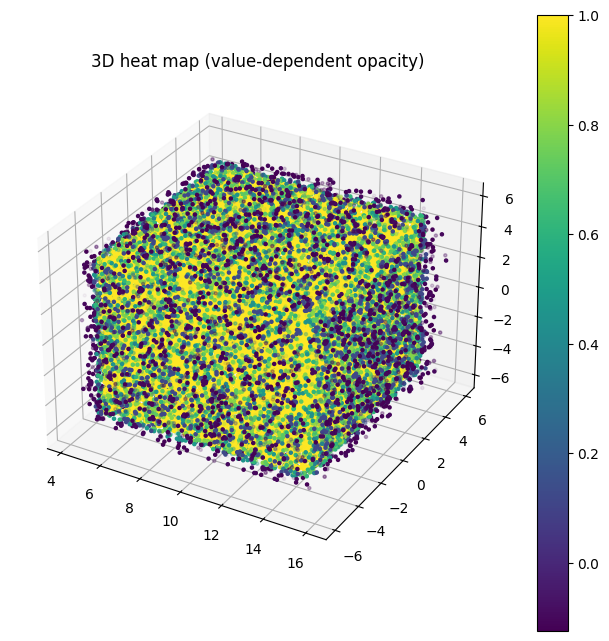

In [5]:
theta_left_at_dofs_interior = theta_left_at_dofs[femsystem.interior_dofs]
theta_right_at_dofs_interior = theta_right_at_dofs[femsystem.interior_dofs]
femsystem.plot_interior_at_quad_3d_heatmap(theta_left_at_dofs_interior)

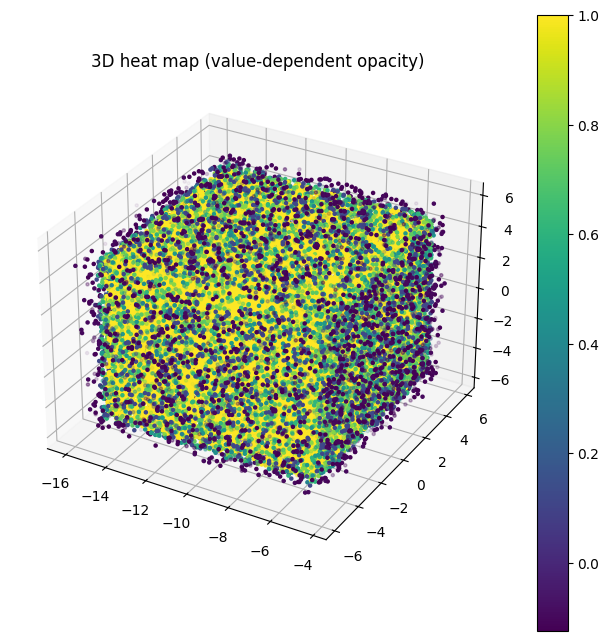

: 

In [ ]:
femsystem.plot_interior_at_quad_3d_heatmap(theta_right_at_dofs_interior)

In [6]:
theta_at_quad = femsystem._interpolate_values(theta_left_at_dofs)
weighted_theta = theta_at_quad * femsystem.weights
v_theta = P_int.T @ weighted_theta.ravel()
# A_int, v_theta are JAX types; use FEMSystem's solver (JAX cg), not scipy's cg
phi_theta_int = femsystem._linear_solve_cg(A_int, v_theta)
femsystem.plot_interior_at_quad_3d_heatmap(phi_theta_int)

NameError: name 'theta_left_at_dofs' is not defined

# Visualize Green's Function

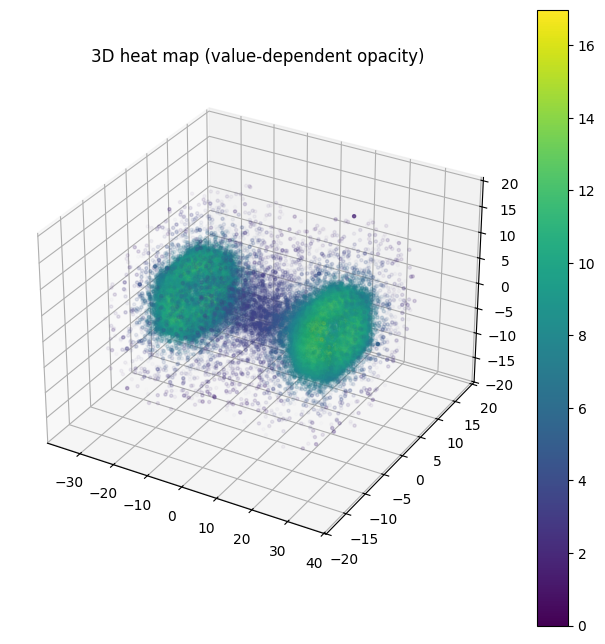

In [4]:
theta_at_quad = femsystem._interpolate_values(theta_at_dofs)
weighted_theta = theta_at_quad * femsystem.weights
v_theta = P_int.T @ weighted_theta.ravel()
phi_theta_int = femsystem._linear_solve_cg(A_int, v_theta)
femsystem.plot_interior_at_quad_3d_heatmap(phi_theta_int)

# Visualize Theta - Volume * ($\phi_L^2$ + $\phi_R^2$)

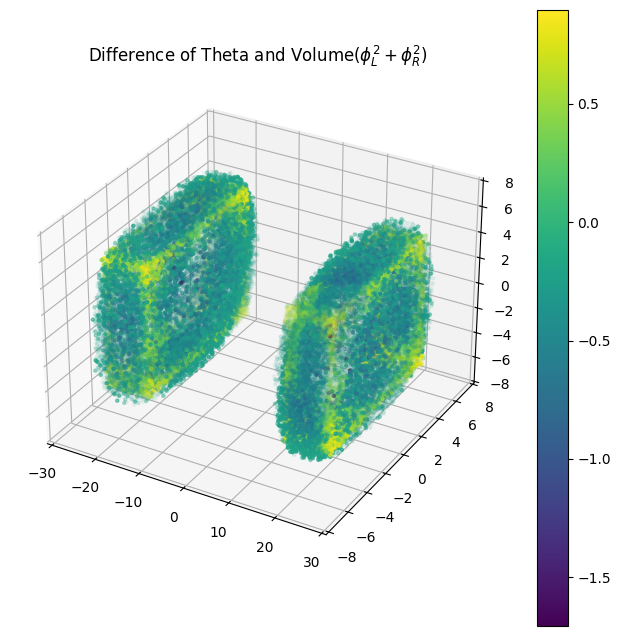

In [5]:
femsystem.plot_interior_at_quad_3d_heatmap(theta_at_interior - integrated_volume * (u_even_interior**2 + u_odd_interior**2),plot_title="Difference of Theta and Volume($\phi_L^2 + \phi_R^2$)")

In [6]:
femsystem.plot_interior_at_quad_3d_heatmap(u_overlap[femsystem.interior_dofs],plot_title=f"Overlap Term ($\phi_L\phi_R$)")

NameError: name 'u_overlap' is not defined

# Visualize Y=Z=0

In [17]:
import numpy as np

# Create a unit vector, of the interior DOFs, where the value is 1 at the single DOF closest to the origin, elsewhere 0
unit_vector = np.zeros(femsystem.interior_dofs.shape[0])
a = jnp.sum(femsystem.doflocs[:,femsystem.interior_dofs]**2,axis=0)
unit_vector[jnp.argmin(a)] = 1

print(unit_vector)
greens_at_origin = femsystem._linear_solve_cg(A_int,unit_vector)
print(greens_at_origin)
# x,vals = vals_x_axis(greens_at_origin)
# print(x,vals)
# plt.plot(x,vals,"-")
# plt.title("Green's Function at Origin")


[0. 0. 0. ... 0. 0. 0.]
[0.00032855 0.00180545 0.00175818 ... 0.00206136 0.00208648 0.0004416 ]


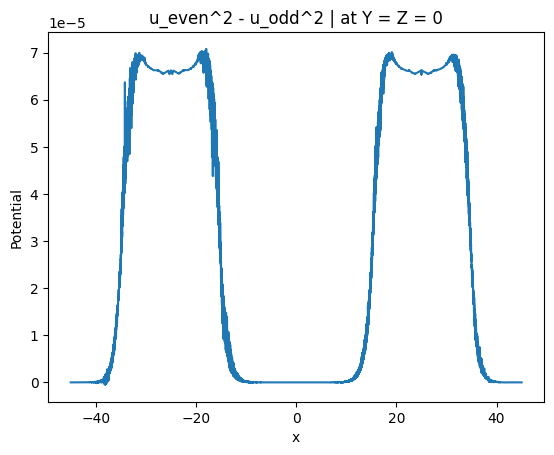

: 

In [ ]:
x,vals = vals_x_axis(jnp.abs(u_odd_interior**2))
plt.title("u_even^2 - u_odd^2 | at Y = Z = 0")
plt.plot(x,vals,"-")
plt.xlabel("x")
plt.ylabel("Potential")
plt.title("u_even^2 - u_odd^2 | at Y = Z = 0")
plt.show()